In [1]:
import pandas as pd

df = pd.read_csv('Housing.csv')

print(df.head())
print(df.columns)

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'baseme

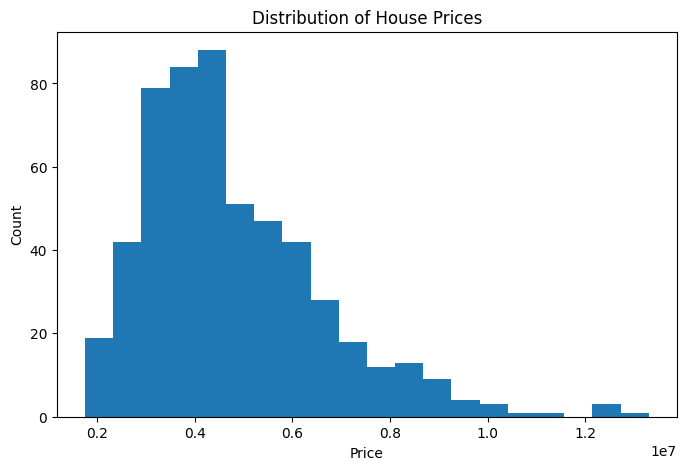

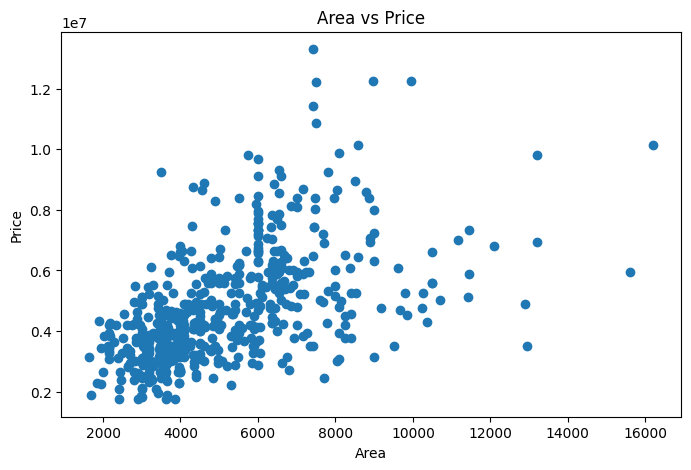

In [2]:
import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=20)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

# Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(df['area'], df['price'])
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = df[['area', 'bedrooms', 'price']].dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

kmeans = KMeans(n_clusters=3, random_state=42)

data['Cluster'] = kmeans.fit_predict(scaled_data)

print(data.head())

   area  bedrooms     price  Cluster
0  7420         4  13300000        2
1  8960         4  12250000        2
2  9960         3  12250000        2
3  7500         4  12215000        2
4  7420         4  11410000        2


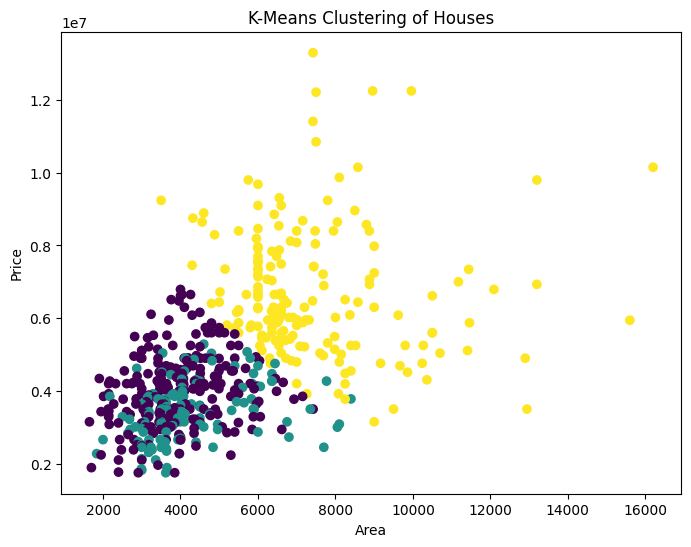

In [4]:
plt.figure(figsize=(8,6))

plt.scatter(
    data['area'],
    data['price'],
    c=data['Cluster']
)

plt.title('K-Means Clustering of Houses')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

In [5]:
print(data['Cluster'].value_counts())

Cluster
0    237
2    180
1    128
Name: count, dtype: int64
